# Add a third modality with TEA-seq

TEA-seq measures RNA, chromatin accessibility, and surface proteins in the same cells.
After the two-modality example in [](cite_seq.ipynb), we now ask whether a joint map retains
recognizable populations and how much each modality contributes locally.

## Open the prepared result

The data come from [Swanson et al. (2021)](https://doi.org/10.7554/eLife.63632).
The prepared store contains 7,069 cells from the
[GSM5123951 Seurat object](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM5123951).
We use the 6,194 cells whose barcodes match the publication's Figure 4 labels. Of the
6,333 labeled well-W3 cells, 139 are absent from this source object.

In [1]:
# Open count stores and run CyteArc analyses.
import cytearc

# Select explicit fields and display options for plots.
from cytearc.plotting import CellField, FeatureRef

# Keep routine logs and progress bars out of the results.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "swanson_7K_pbmc_teaseq",
    destination="cytearc_datasets",
    zarr=True,
)

# Open the count store for this analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", default_assay="RNA", nthreads=4)

# Inspect the opened store's cells and features.
ds

DataStore has 6194 (7069) cells with 3 assays: ADT ATAC RNA
   Cell metadata:
            'I', 'ids', 'names', 'ADT_UMAP1', 'ADT_UMAP2', 
            'ADT_leiden_cluster', 'ADT_nCounts', 'ADT_nFeatures', 'ATAC_UMAP1', 'ATAC_UMAP2', 
            'ATAC_leiden_cluster', 'ATAC_nCounts', 'ATAC_nFeatures', 'DoubletEnrichment', 'DoubletScore', 
            'RNA+ATAC+ADT_UMAP1', 'RNA+ATAC+ADT_UMAP2', 'RNA+ATAC+ADT_leiden_cluster', 'RNA+ATAC+ADT_wnn_UMAP1', 'RNA+ATAC+ADT_wnn_UMAP2', 
            'RNA+ATAC+ADT_wnn_leiden_cluster', 'RNA_UMAP1', 'RNA_UMAP2', 'RNA_leiden_cluster', 'RNA_nCounts', 
            'RNA_nFeatures', 'TSSEnrichment', 'altius_count', 'altius_frac', 'barcodes', 
            'batch_id', 'cell_name', 'chip_id', 'gene_bodies_count', 'gene_bodies_frac', 
            'nCount_ADT', 'nCount_ATAC', 'nCount_RNA', 'nFeature_ADT', 'nFeature_ATAC', 
            'nFeature_RNA', 'n_duplicate', 'n_fragments', 'n_mito', 'n_unique', 
            'orig.ident', 'original_barcodes', 'pbmc_sample

Started: 2026-10-08T13:04:59.083402Z | Wall time: 26.098 s

Import and preprocessing are already complete. RNA uses log-transformed library-size
normalization, ATAC uses TF-IDF, and ADT uses CLR normalization. All three neighbor
results describe the same selected cells.

## Compare the separate views

First look for the labeled populations in each modality. Independent UMAPs can rotate
and rearrange, so compare population neighborhoods rather than absolute positions or
island sizes. A population's labels and cell count are the same in all three panels.

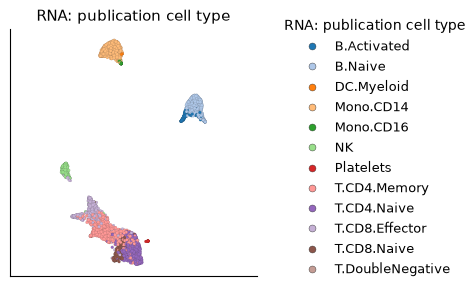

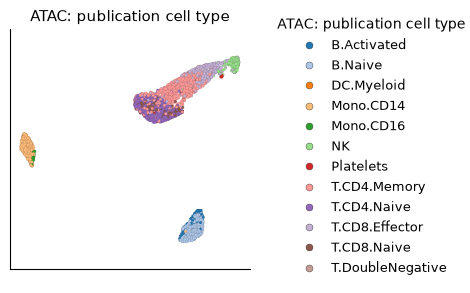

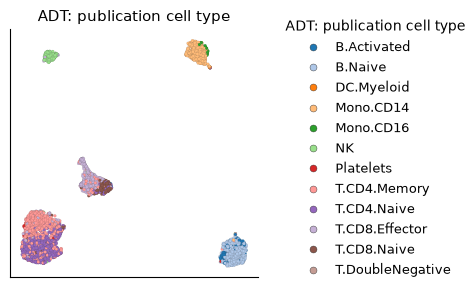

Started: 2026-10-08T13:05:25.186049Z | Wall time: 2.989 s

In [2]:
# Inspect the RNA, ATAC, and protein views in turn.
for assay in ("RNA", "ATAC", "ADT"):

    # Select the saved layout for this assay; require exactly one match.
    layout = ds.artifacts.find("embedding", from_assay=assay, method="umap")

    # Name the modality on its UMAP and color cells by the publication labels.
    ds.plots.embedding(
        layout=layout,
        color_by=CellField("tea_cell_type", label=f"{assay}: publication cell type"),
    )

Differences between these views may reflect complementary measurements or technical
noise. A more compact population is not, by itself, evidence of a better analysis.

## Inspect the joint WNN map

Select the saved WNN graph and the UMAP made from it:

In [3]:
# Select the saved WNN graph; require exactly one match.
wnn_graph = ds.artifacts.find("graph", method="wnn")

# Select the saved WNN layout; require exactly one match.
wnn_layout = ds.artifacts.find("embedding", graph=wnn_graph, method="umap")

# Inspect the selected WNN graph and its matching layout.
{"WNN graph": wnn_graph, "WNN layout": wnn_layout}

{'WNN graph': ArtifactRef(datastore, kind='integrated_graph', artifact_id='1e41216fedf4...'),
 'WNN layout': ArtifactRef(datastore, kind='embedding', artifact_id='e7a6491edd86...')}

Started: 2026-10-08T13:05:28.179981Z | Wall time: 0.017 s

Now compare the publication labels with four measured protein markers on the joint map.

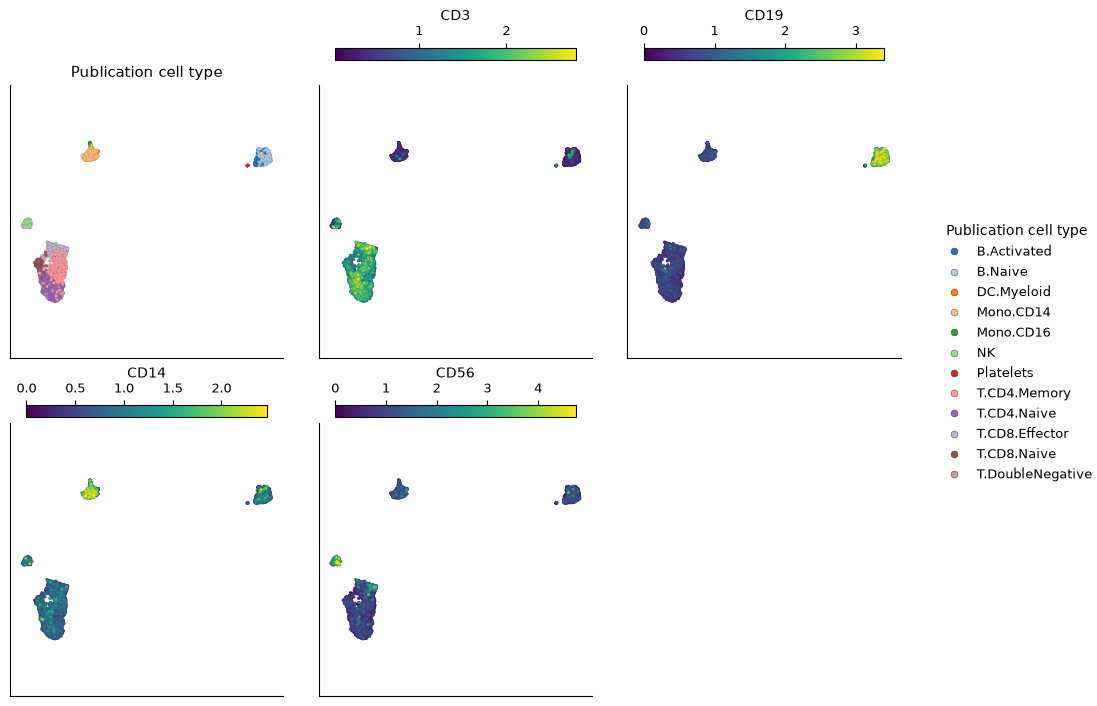

Started: 2026-10-08T13:05:28.199908Z | Wall time: 2.440 s

In [4]:
# Compare publication labels with four protein markers on the WNN map.
ds.plots.embedding(
    layout=wnn_layout,
    color_by=[
        CellField("tea_cell_type", label="Publication cell type"),
        FeatureRef("CD3", assay="ADT"),
        FeatureRef("CD19", assay="ADT"),
        FeatureRef("CD14", assay="ADT"),
        FeatureRef("CD56", assay="ADT"),
    ],
    n_columns=3,
    sort_values=True,
)

CD3, CD19, CD14, and CD56 support T-cell, B-cell, monocyte, and NK-like regions,
respectively. Agreement with the publication labels is useful evidence, but does not
validate every neighborhood. This UMAP is a CyteArc analysis, not a reproduction of the
publication's layout.

## See which modality contributes locally

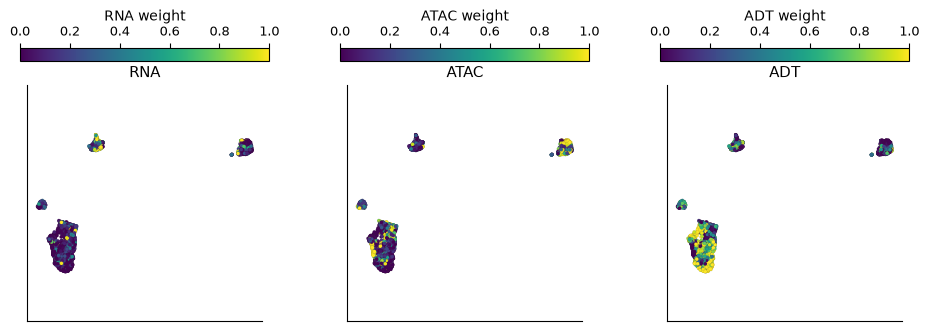

Started: 2026-10-08T13:05:30.643239Z | Wall time: 1.108 s

In [5]:
# Show how much each modality contributes across the joint map.
ds.plots.modality_weights(graph=wnn_graph, layout=wnn_layout)

A high weight means a modality contributes more to that cell's WNN neighborhood under
these preprocessing choices. It does not measure molecular abundance, overall assay
quality, or a cause of cell identity. Look for regions where the weights differ, then
return to the marker and single-modality maps to interpret those differences.

To check how sensitive the result is to integration choices, continue to
[](multimodal_diagnostics.ipynb). The weighting equations and differences from Seurat are
covered in [Integration and metrics API reference](/api/integration.html).